In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
dataset_path = "dataset"

IMG_SIZE = 224
BATCH_SIZE = 32

In [3]:
parasitized_path = os.path.join(dataset_path, "Parasitized")
uninfected_path = os.path.join(dataset_path, "Uninfected")

print("Parasitized images:", len(os.listdir(parasitized_path)))
print("Uninfected images:", len(os.listdir(uninfected_path)))

Parasitized images: 13780
Uninfected images: 13780


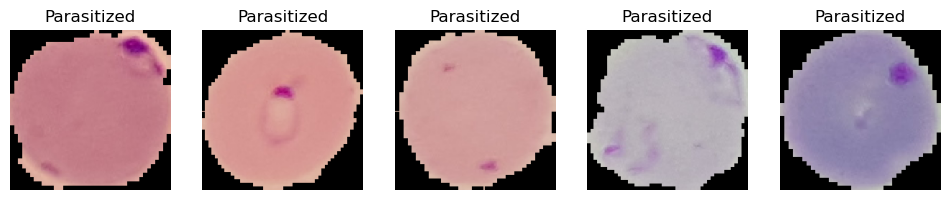

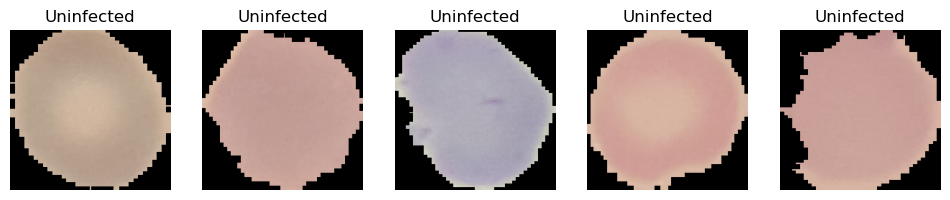

In [4]:
import random
from tensorflow.keras.preprocessing import image

def show_samples(folder, label):
    images = random.sample(os.listdir(folder), 5)

    plt.figure(figsize=(12,4))

    for i,img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        img = image.load_img(img_path, target_size=(IMG_SIZE,IMG_SIZE))

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

    plt.show()

show_samples(parasitized_path,"Parasitized")
show_samples(uninfected_path,"Uninfected")

In [5]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


In [6]:
print(train_generator.class_indices)

{'Parasitized': 0, 'Uninfected': 1}


In [7]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [8]:
for layer in base_model.layers:
    layer.trainable = False

In [11]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_efficientnet_malaria_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

In [14]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.5004 - loss: 0.7518

689/689 ━━━━━━━━━━━━━━━━━━━━ 483s 690ms/step - accuracy: 0.5012 - loss: 0.7361 - val_accuracy: 0.5000 - val_loss: 0.6934 - learning_rate: 1.0000e-04
Epoch 2/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 468s 679ms/step - accuracy: 0.5061 - loss: 0.7201 - val_accuracy: 0.5000 - val_loss: 0.6948 - learning_rate: 1.0000e-04
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 485s 703ms/step - accuracy: 0.5016 - loss: 0.7175 - val_accuracy: 0.5000 - val_loss: 0.6915 - learning_rate: 1.0000e-04
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.5105 - loss: 0.7128

689/689 ━━━━━━━━━━━━━━━━━━━━ 490s 712ms/step - accuracy: 0.5130 - loss: 0.7115 - val_accuracy: 0.5693 - val_loss: 0.6909 - learning_rate: 1.0000e-04
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.5157 - loss: 0.7075

689/689 ━━━━━━━━━━━━━━━━━━━━ 466s 677ms/step - accuracy: 0.5137 - loss: 0.7077 - val_accuracy: 0.5849 - val_loss: 0.6911 - learning_rate: 1.0000e-04
Epoch 6/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 484s 703ms/step - accuracy: 0.5114 - loss: 0.7066 - val_accuracy: 0.5775 - val_loss: 0.6898 - learning_rate: 1.0000e-04
Epoch 7/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 483s 702ms/step - accuracy: 0.5186 - loss: 0.7038 - val_accuracy: 0.5074 - val_loss: 0.6906 - learning_rate: 1.0000e-04
Epoch 8/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 477s 693ms/step - accuracy: 0.5161 - loss: 0.7039 - val_accuracy: 0.5069 - val_loss: 0.6905 - learning_rate: 1.0000e-04
Epoch 9/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.5173 - loss: 0.7028

689/689 ━━━━━━━━━━━━━━━━━━━━ 480s 696ms/step - accuracy: 0.5186 - loss: 0.7030 - val_accuracy: 0.6020 - val_loss: 0.6898 - learning_rate: 1.0000e-04
Epoch 10/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 485s 704ms/step - accuracy: 0.5176 - loss: 0.6997 - val_accuracy: 0.5376 - val_loss: 0.6898 - learning_rate: 2.0000e-05
Epoch 11/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 478s 694ms/step - accuracy: 0.5147 - loss: 0.6990 - val_accuracy: 0.5795 - val_loss: 0.6902 - learning_rate: 2.0000e-05
Epoch 12/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 481s 698ms/step - accuracy: 0.5203 - loss: 0.6994 - val_accuracy: 0.5481 - val_loss: 0.6901 - learning_rate: 2.0000e-05
Epoch 13/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 483s 701ms/step - accuracy: 0.5255 - loss: 0.6965 - val_accuracy: 0.5639 - val_loss: 0.6898 - learning_rate: 4.0000e-06
Epoch 14/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 470s 683ms/step - accuracy: 0.5181 - loss: 0.6988 - val_accuracy: 0.5546 - val_loss: 0.6901 - learning_rate: 4.0000e-06
Epoch 15/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 454s 

In [15]:
val_loss, val_acc = model.evaluate(val_generator)

print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)

173/173 ━━━━━━━━━━━━━━━━━━━━ 90s 521ms/step - accuracy: 0.5639 - loss: 0.6898
Validation Accuracy: 0.5638838410377502
Validation Loss: 0.6897913813591003


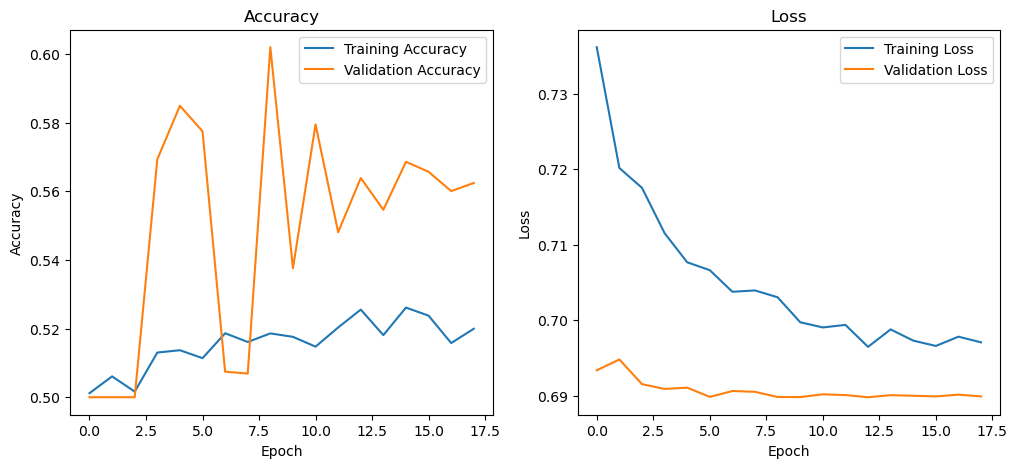

In [16]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

173/173 ━━━━━━━━━━━━━━━━━━━━ 93s 530ms/step


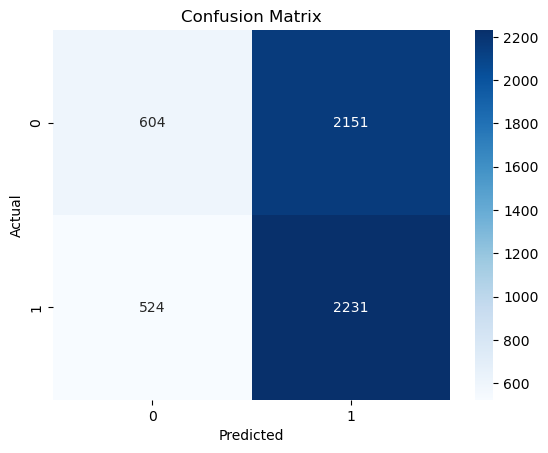

In [17]:
val_generator.reset()

predictions = model.predict(val_generator)
pred_labels = (predictions > 0.5).astype(int)

cm = confusion_matrix(val_generator.classes, pred_labels)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [18]:
print(classification_report(val_generator.classes, pred_labels))

              precision    recall  f1-score   support

           0       0.54      0.22      0.31      2755
           1       0.51      0.81      0.63      2755

    accuracy                           0.51      5510
   macro avg       0.52      0.51      0.47      5510
weighted avg       0.52      0.51      0.47      5510



In [19]:
model.save("efficientnet_malaria_model.h5")